# Desafio 015

Bem-vindo à análise de dados financeiros. Desta vez, vamos simular uma base de dados de transações e investimentos de uma fintech ou corretora de valores.

Abaixo está o seu ponto de partida, já configurado com 100 linhas e dados simulados via código.

### Seu código inicial:

In [2]:
import pandas as pd
import numpy as np

# Garantir que os dados gerados sejam sempre os mesmos
np.random.seed(101)

# Gerando 100 registros de transações financeiras
n_linhas = 100

dados_financeiros = {
    'ID_Transacao': list(range(5001, 5001 + n_linhas)),
    'ID_Cliente': np.random.randint(100, 125, size=n_linhas), # 25 clientes únicos
    'Data_Transacao': pd.date_range(start='2026-01-01', periods=n_linhas, freq='12h'),
    'Tipo_Ativo': np.random.choice(['Ação', 'FII', 'Renda Fixa', 'Cripto'], size=n_linhas),
    'Operacao': np.random.choice(['Compra', 'Venda'], size=n_linhas, p=[0.6, 0.4]), # 60% compra, 40% venda
    'Valor_Total': np.round(np.random.exponential(scale=1500, size=n_linhas) + 50, 2),
    'Taxa_Corretagem': np.round(np.random.uniform(0.5, 15.0, size=n_linhas), 2),
    'Status': np.random.choice(['Concluída', 'Processando', 'Falhou'], size=n_linhas, p=[0.85, 0.10, 0.05])
}

df_financeiro = pd.DataFrame(dados_financeiros)

In [3]:
df_financeiro.head()

,ID_Transacao,ID_Cliente,Data_Transacao,Tipo_Ativo,Operacao,Valor_Total,Taxa_Corretagem,Status
0,5001,111,2026-01-01 00:00:00,Cripto,Compra,99.63,8.56,Concluída
1,5002,117,2026-01-01 12:00:00,Renda Fixa,Compra,1516.88,7.55,Concluída
2,5003,106,2026-01-02 00:00:00,Ação,Compra,3189.82,8.71,Concluída
3,5004,123,2026-01-02 12:00:00,Cripto,Compra,199.34,12.60,Concluída
4,5005,111,2026-01-03 00:00:00,Cripto,Compra,489.62,7.81,Concluída


### Suas 8 Perguntas para Responder com Pandas:

Para este relatório financeiro, você deve responder às seguintes perguntas utilizando filtros, agrupamentos (groupby) e agregações:

1. **Filtro Simples**: Quantas operações de "Compra" foram realizadas com o tipo de ativo "Cripto"?

In [4]:
cripto = df_financeiro[(df_financeiro["Operacao"] == "Compra") & (df_financeiro["Tipo_Ativo"] == "Cripto")]
cripto = cripto["ID_Transacao"].count()
print(f"Foram realizadas {cripto} operações de compra de cripto")

Foram realizadas 21 operações de compra de cripto


2. **Agregação**: Qual é o valor total acumulado movimentado (Compra + Venda) para cada um dos quatro tipos de ativos (Tipo_Ativo)?

In [5]:
df_financeiro["Valor_Total"] = df_financeiro["Valor_Total"].abs()
display(df_financeiro.groupby("Tipo_Ativo")["Valor_Total"].sum())

Tipo_Ativo
Ação          24779.83
Cripto        57017.18
FII           47639.80
Renda Fixa    31609.25
Name: Valor_Total, dtype: float64

3. **Filtragem de Falhas**: Quais transações resultaram em Status "Falhou" e tinham um Valor_Total superior a R$ 2.000,00?

In [6]:
display(df_financeiro[(df_financeiro["Status"] == "Falhou") & (df_financeiro["Valor_Total"] > 2000)])

,ID_Transacao,ID_Cliente,Data_Transacao,Tipo_Ativo,Operacao,Valor_Total,Taxa_Corretagem,Status
24,5025,112,2026-01-13 00:00:00,Renda Fixa,Venda,2277.07,9.88,Falhou
59,5060,117,2026-01-30 12:00:00,Cripto,Venda,2927.55,3.55,Falhou
96,5097,114,2026-02-18 00:00:00,Cripto,Compra,5016.16,9.53,Falhou


4. **Análise de Clientes**: Qual ID_Cliente gerou o maior valor em Taxa_Corretagem para a corretora?

In [7]:
maior_taxa = df_financeiro.groupby("ID_Cliente")["Taxa_Corretagem"].sum().max()
id_maior_taxa = df_financeiro.groupby("ID_Cliente")["Taxa_Corretagem"].sum().idxmax()
print(f"O cliente com maior valor em Taxa_Corretagem foi o cliente com ID {id_maior_taxa} que pagou um total de R${maior_taxa:.2f} reais.")

O cliente com maior valor em Taxa_Corretagem foi o cliente com ID 119 que pagou um total de R$87.68 reais.


5. **Visão Temporal**: Qual foi o valor total negociado por mês (Dica: use .dt.to_period('M') na coluna de data)?

In [8]:
df_financeiro["Mes"] = df_financeiro["Data_Transacao"].dt.strftime("%B")
valor_mensal = df_financeiro.groupby("Mes")["Valor_Total"].sum()
print(valor_mensal)

Mes
February    65329.03
January     95717.03
Name: Valor_Total, dtype: float64


6. **Análise de Lucratividade**: Considerando apenas as operações "Concluídas", qual o valor médio gasto por transação nas operações de "Compra" versus o valor médio recebido nas de "Venda"?

In [9]:
media_concluida = df_financeiro[df_financeiro["Status"] == "Concluída"].groupby("Operacao")["Valor_Total"].mean()
display(media_concluida)

Operacao
Compra    1504.857755
Venda     1986.356875
Name: Valor_Total, dtype: float64

7. **Visualização 1** (Barras): Crie um gráfico de barras que mostre a quantidade de transações por Status para cada Tipo_Ativo.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
grafico1 = df_financeiro.groupby(["Status", "Tipo_Ativo"]).size().reset_index(name="Quantidade")

display(grafico1)

,Status,Tipo_Ativo,Quantidade
0,Concluída,Ação,18
1,Concluída,Cripto,25
2,Concluída,FII,24
3,Concluída,Renda Fixa,14
4,Falhou,Ação,1
5,Falhou,Cripto,4
6,Falhou,Renda Fixa,4
7,Processando,Ação,5
8,Processando,FII,2
9,Processando,Renda Fixa,3


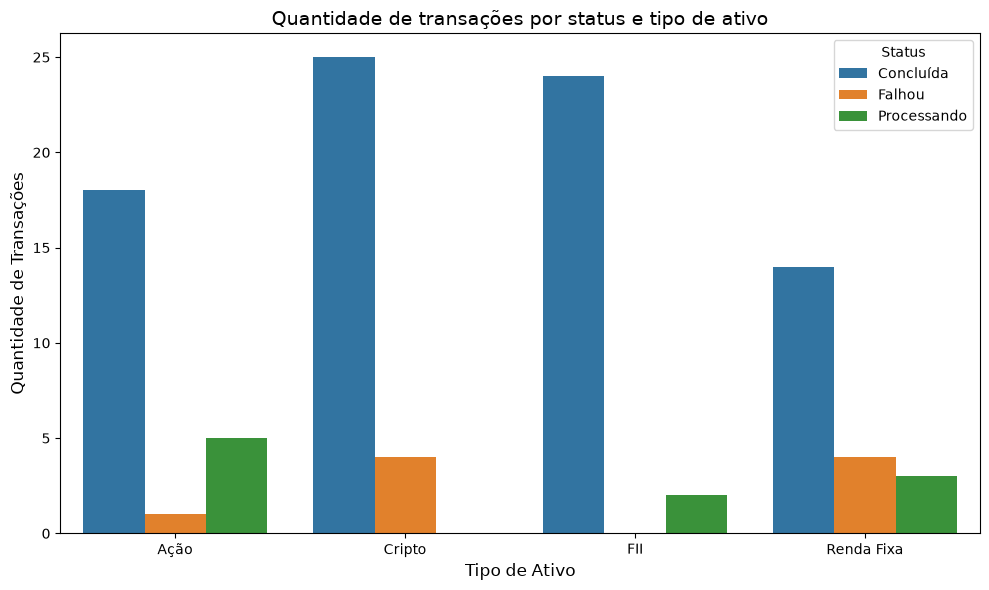

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grafico1,
    x="Tipo_Ativo",
    y="Quantidade",
    hue="Status"
)
plt.title(
    "Quantidade de transações por status e tipo de ativo",
    fontsize=14
)
plt.xlabel("Tipo de Ativo", fontsize=12)
plt.ylabel("Quantidade de Transações", fontsize=12)
plt.legend(title="Status")

plt.tight_layout()
plt.show()

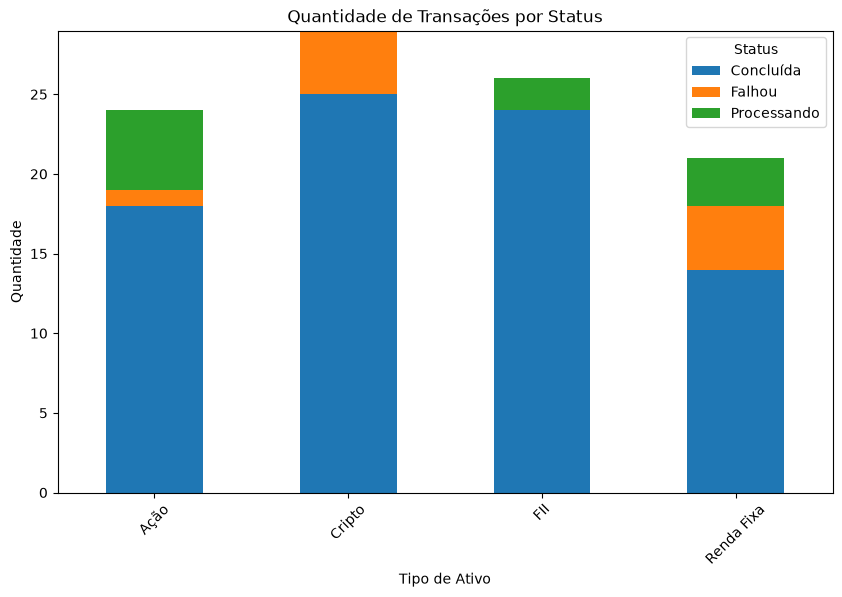

In [13]:
grafico_pivot = grafico1.pivot(
    index="Tipo_Ativo",
    columns="Status",
    values="Quantidade"
).fillna(0)

grafico_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Quantidade de Transações por Status")
plt.xlabel("Tipo de Ativo")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

8. **Visualização 2** (Linha): Crie um gráfico de linha que demonstre a evolução do valor de Taxa_Corretagem arrecadado ao longo do tempo.

In [14]:
df_financeiro["Data_Transacao"] = pd.to_datetime(df_financeiro["Data_Transacao"])

In [18]:
evolucao = df_financeiro.groupby("Mes")["Taxa_Corretagem"].sum().reset_index()

display(evolucao)

,Mes,Taxa_Corretagem
0,February,305.86
1,January,549.26


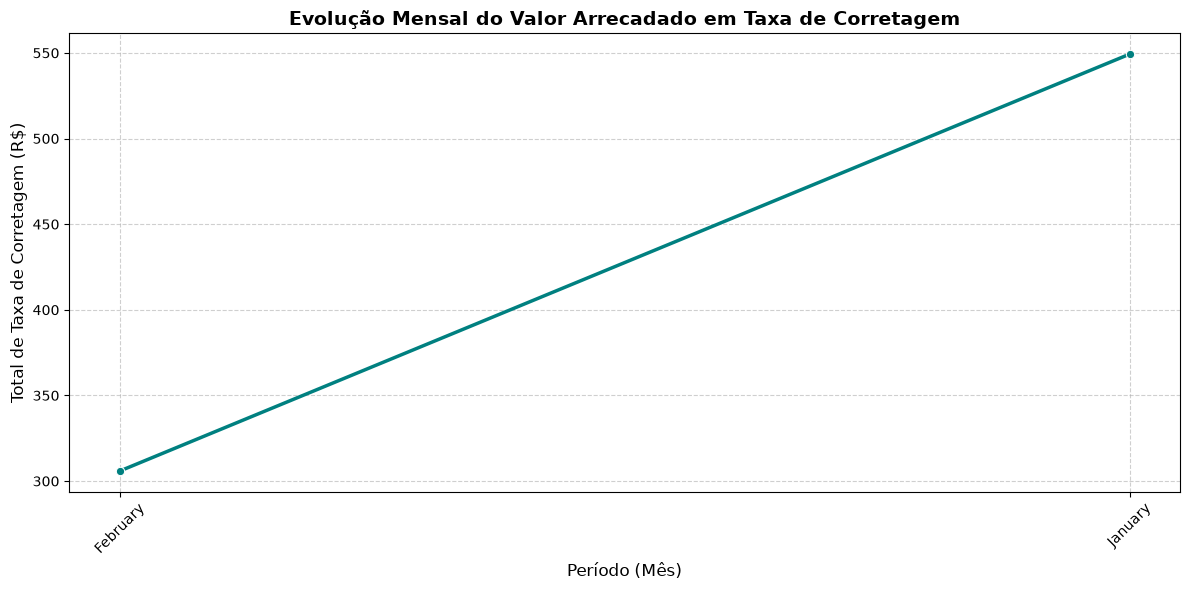

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=evolucao,
    x="Mes",
    y="Taxa_Corretagem",
    marker="o",
    color="teal",
    linewidth=2.5
)

plt.title(
    "Evolução Mensal do Valor Arrecadado em Taxa de Corretagem",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Período (Mês)",
    fontsize=12
)
plt.ylabel(
    "Total de Taxa de Corretagem (R$)",
    fontsize=12
)
plt.xticks(rotation=45)
plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)
plt.tight_layout()
plt.show()